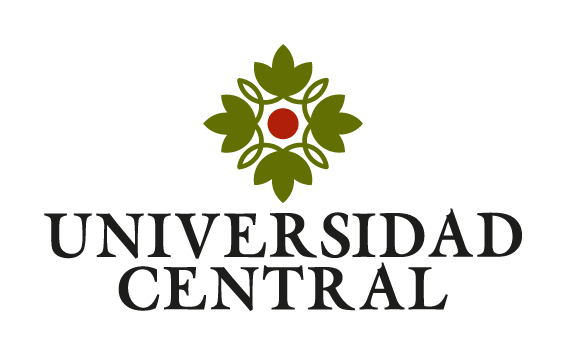

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 16 de 2026

Taller: Trabajo Final

# Etapa 4 (Parte A): RAG — Generación con Llama 3 y Mistral

Este notebook conecta el motor de retrieval (Etapa 3) con dos LLMs para generar **respuestas ancladas** con citas al fragmento jurídico exacto.

## Arquitectura del RAG
1. **Usuario** → consulta jurídica en lenguaje natural
2. **Retrieval** → ChromaDB devuelve top-k chunks relevantes (con coseno y filtros)
3. **Parent-document expansion** → si hay tablas, se trae el bloque padre como contexto
4. **Prompt construction** → contexto + consulta + instrucciones jurídicas
5. **Generación** → Llama 3 y Mistral generan respuestas en paralelo
6. **Output** → respuesta + citas (filename, numeral, página) + JSON con ambos resultados para comparación

## Modelos comparados
- **Llama 3** (`meta-llama/Meta-Llama-3-8B-Instruct`) — requiere token HF (gated)
- **Mistral** (`mistralai/Mistral-7B-Instruct-v0.3`) — abierto
- Ambos se cargan con cuantización 4-bit para caber en una T4 (16 GB VRAM)

## Salida

| Archivo | Contenido |
|---|---|
| `respuestas_<timestamp>.json` | Corpus completo de respuestas (entrada del dashboard) |
| `comparacion_modelos.csv` | Resumen tabular para análisis comparativo |
| `last_respuestas.json` | Apunta al JSON más reciente (cómo lo encuentra el dashboard) |

# HOJA DE RUTA A SEGUIR

0. Montar Google Drive
1. Instalar dependencias
2. Instalar Librerías
3. Configuración de Rutas
4. Autenticación HuggingFace (necesario para Llama 3)
5. Cargar Motor de Retrieval (Etapa 3)
6. Configuración de Cuantización 4-bit
7. Clase Generador (wrapper unificado para ambos modelos)
8. Construcción del Prompt Jurídico
9. Función responder_rag — orquesta retrieval + generación
10. Catálogo de consultas para comparar los modelos
11. Ejecución Comparada: Mistral → Llama 3
11.1 Mistral 7B Instruct
11.2 Llama 3 8B Instruct
12. Guardar resultados completos
13. Comparación rápida entre modelos



# 0\. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1\. Instalar dependencias

Después de ejecutar esta celda, **reinicia el runtime** y ejecuta desde la celda 3.

In [ ]:
!pip install -q "numpy<2.0" "pandas>=2.0,<2.3" \
    chromadb==0.5.5 langchain==0.3.0 langchain-community==0.3.0 \
    "transformers>=4.46,<4.50" sentencepiece tqdm \
    "accelerate>=0.34" "bitsandbytes>=0.45.2"

print('\n' + '=' * 60)
print('⚠ AHORA ES NECESARIO REINICIAS EL RUNTIME y continuar desde la celda 3')
print('  Menú: Entorno de ejecución → Reiniciar sesión')
print('=' * 60)


⚠ AHORA REINICIA EL RUNTIME y continúa desde la celda 2
  Menú: Entorno de ejecución → Reiniciar sesión


# 2\. Instalar Librerías

In [ ]:
import os
import json
import sys
import time
from datetime import datetime
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

#3\. Configuración de Rutas

In [ ]:
# Rutas
BASE_DIR        = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final'
RETRIEVAL_DIR   = os.path.join(BASE_DIR, 'Retrieval')
CHROMA_DIR      = os.path.join(RETRIEVAL_DIR, 'chroma_db')
GENERACION_DIR  = os.path.join(BASE_DIR, 'Generacion')
os.makedirs(GENERACION_DIR, exist_ok=True)

# Importar la clase Retriever exportada por la Etapa 3
sys.path.append(RETRIEVAL_DIR)
from retriever_utils import Retriever

print(f'Chroma:    {CHROMA_DIR}')
print(f'Salida:    {GENERACION_DIR}')
print(f'Torch:     {torch.__version__}')
print(f'GPU:       {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU — activa T4 en Runtime"}')

Chroma:    /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/chroma_db
Salida:    /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion
Torch:     2.10.0+cu128
GPU:       Tesla T4


# 4\. Autenticación HuggingFace (necesario para Llama 3)

Si solo se usa Mistral se puede obviar esta. Si se usa Llama 3, es necesario haber aceptado los términos en https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct y tener un token con permisos de read.

In [ ]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

print("✅ Autenticación vinculada mediante Secrets de Colab")

✅ Autenticación vinculada mediante Secrets de Colab


#5\. Cargar Motor de Retrieval (Etapa 3)

In [ ]:
print('Cargando Retriever (Longformer + ChromaDB)...')
retriever = Retriever(chroma_dir=CHROMA_DIR)
print(f'✓ Retriever listo. Chunks indexados: {retriever.collection.count()}')

Cargando Retriever (Longformer + ChromaDB)...


model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


✓ Retriever listo. Chunks indexados: 139


#6\. Configuración de Cuantización 4-bit

Llama 3 8B y Mistral 7B en fp16 ocupan ~16 GB cada uno (no caben en T4). Con 4-bit ocupan ~5 GB → ambos caben con margen.

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
print('Configuración bnb (4-bit nf4) lista.')

Configuración bnb (4-bit nf4) lista.


#7\. Clase Generador (wrapper unificado para ambos modelos)

Cada modelo tiene su propio formato de chat template; la clase los abstrae para que el resto del notebook los use igual.

In [ ]:
class GeneradorLLM:
    """Wrapper para Llama 3 / Mistral con cuantización 4-bit."""

    def __init__(self, model_id: str, nombre_corto: str):
        self.model_id = model_id
        self.nombre = nombre_corto
        print(f'\nCargando {nombre_corto} ({model_id})... esto puede tardar 3-5 min')
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map='auto',
            torch_dtype=torch.float16,
        )
        self.model.eval()
        print(f'✓ {nombre_corto} cargado')

    def generar(self, mensajes: list, max_new_tokens: int = 600, temperature: float = 0.2) -> str:
        """mensajes: lista de dicts [{'role': 'system'|'user'|'assistant', 'content': '...'}]"""
        prompt = self.tokenizer.apply_chat_template(
            mensajes, tokenize=False, add_generation_prompt=True
        )
        inputs = self.tokenizer(prompt, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=temperature > 0,
                top_p=0.9,
                pad_token_id=self.tokenizer.pad_token_id,
            )
        # Decodificar solo lo nuevo (no el prompt)
        respuesta = self.tokenizer.decode(
            outputs[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True,
        )
        return respuesta.strip()

    def liberar(self):
        """Libera VRAM antes de cargar el siguiente modelo."""
        del self.model
        del self.tokenizer
        torch.cuda.empty_cache()
        print(f'✓ {self.nombre} liberado de VRAM')

#8\. Construcción del Prompt Jurídico

El prompt instruye al LLM a:
- Responder solo con base en el contexto provisto (anti-alucinación)
- Citar siempre el `filename`, `numeral` y `página`
- Si no encuentra respuesta, decirlo explícitamente
- Mantener tono jurídico-técnico

In [ ]:
SYSTEM_PROMPT = """Eres un asistente jurídico especializado en derecho ambiental colombiano, particularmente en Autos de Apertura de procedimientos sancionatorios de la Autoridad Nacional de Licencias Ambientales (ANLA).

Tu tarea es responder consultas jurídicas basándote ESTRICTAMENTE en los fragmentos de contexto que se te proporcionan. Reglas obligatorias:

1. Responde SOLO con información presente en el contexto. Si el contexto no contiene la respuesta, di explícitamente: "La información solicitada no se encuentra en los documentos consultados."
2. NO inventes hechos, fechas, numerales, normas ni decisiones.
3. Para cada afirmación relevante, cita la fuente en formato: [Documento: <filename>, Numeral: <numeral>, Página: <pag>]
4. Usa un tono jurídico-técnico, preciso y formal.
5. Si el contexto contiene tablas, identifícalas y resume su contenido relevante.
6. Estructura la respuesta así: (a) Respuesta directa, (b) Fundamentos del contexto con citas, (c) Limitaciones si aplican."""


def construir_contexto(chunks_recuperados: List[Dict], incluir_padres: bool = True) -> str:
    """Formatea los chunks recuperados como contexto numerado para el LLM."""
    bloques = []
    padres_vistos = set()

    for i, ch in enumerate(chunks_recuperados, 1):
        md = ch['metadata']
        encabezado = (
            f"[Fragmento {i}] Documento: {md['filename']} | "
            f"Tipo: {md['tipo_chunk']} | Numeral: {md['numeral']} | "
            f"Página: {md['pagina_inicio']}-{md['pagina_fin']} | "
            f"Similitud: {ch['similitud']:.3f}"
        )
        bloques.append(f"{encabezado}\n{ch['texto']}")

        # Parent-document expansion para tablas
        if incluir_padres and md['tipo_chunk'] == 'tabla':
            padre = retriever.traer_bloque_padre(ch)
            if padre and padre['bloque_id'] not in padres_vistos:
                padres_vistos.add(padre['bloque_id'])
                bloques.append(
                    f"[Contexto del Fragmento {i} — bloque padre]\n"
                    f"Numeral: {padre['numeral']} | Título: {padre['titulo']}\n"
                    f"{padre['texto_completo'][:1500]}"
                )
    return '\n\n---\n\n'.join(bloques)


def construir_mensajes(query: str, contexto: str) -> list:
    user_prompt = f"""CONTEXTO (fragmentos extraídos de los Autos de Apertura ANLA):

{contexto}

---

CONSULTA JURÍDICA:
{query}

Responde siguiendo las reglas establecidas."""
    return [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_prompt},
    ]

print('Funciones de prompt definidas.')

Funciones de prompt definidas.


#9\. Función `responder_rag` — orquesta retrieval + generación

In [ ]:
def responder_rag(
    query: str,
    generador: GeneradorLLM,
    top_k: int = 5,
    tipo_chunk: Optional[str] = None,
    filename: Optional[str] = None,
    fecha_desde: Optional[str] = None,
    fecha_hasta: Optional[str] = None,
    incluir_padres: bool = True,
    max_new_tokens: int = 600,
    temperature: float = 0.2,
) -> dict:
    """Ejecuta el pipeline RAG completo y devuelve respuesta + trazabilidad."""
    t0 = time.time()

    # 1) Retrieval
    chunks = retriever.buscar(
        query, top_k=top_k, tipo_chunk=tipo_chunk,
        filename=filename, fecha_desde=fecha_desde, fecha_hasta=fecha_hasta,
    )
    t_retrieval = time.time() - t0

    if not chunks:
        return {
            'query': query,
            'modelo': generador.nombre,
            'respuesta': 'No se encontraron fragmentos relevantes con los filtros aplicados.',
            'chunks_recuperados': [],
            'tiempo_retrieval_s': round(t_retrieval, 2),
            'tiempo_generacion_s': 0,
        }

    # 2) Construir contexto
    contexto = construir_contexto(chunks, incluir_padres=incluir_padres)
    mensajes = construir_mensajes(query, contexto)

    # 3) Generación
    t1 = time.time()
    respuesta = generador.generar(mensajes, max_new_tokens=max_new_tokens, temperature=temperature)
    t_generacion = time.time() - t1

    # 4) Devolver con trazabilidad
    return {
        'query': query,
        'modelo': generador.nombre,
        'respuesta': respuesta,
        'chunks_recuperados': [
            {
                'chunk_id': c['chunk_id'],
                'similitud': round(c['similitud'], 4),
                'tipo_chunk': c['metadata']['tipo_chunk'],
                'filename': c['metadata']['filename'],
                'numeral': c['metadata']['numeral'],
                'pagina_inicio': c['metadata']['pagina_inicio'],
                'pagina_fin': c['metadata']['pagina_fin'],
                'texto_preview': c['texto'][:200],
            } for c in chunks
        ],
        'parametros': {
            'top_k': top_k, 'tipo_chunk': tipo_chunk, 'filename': filename,
            'fecha_desde': fecha_desde, 'fecha_hasta': fecha_hasta,
            'incluir_padres': incluir_padres, 'temperature': temperature,
        },
        'tiempo_retrieval_s': round(t_retrieval, 2),
        'tiempo_generacion_s': round(t_generacion, 2),
    }

print('Función responder_rag() definida.')

Función responder_rag() definida.


#10\. Catálogo de consultas para comparar los modelos

Se define un conjunto de consultas representativas de los Autos ANLA. Cada modelo responderá cada consulta y se guardan los resultados para el dashboard.

In [ ]:
CONSULTAS_EVALUACION = [
    {
        'id': 'q01',
        'pregunta': '¿Cuál es la competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q02',
        'pregunta': '¿Qué hechos motivan la apertura del procedimiento sancionatorio en estos autos?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q03',
        'pregunta': '¿Qué requerimientos del concepto técnico se mantienen y cuáles se modifican?',
        'filtros': {'tipo_chunk': 'tabla'},
    },
    {
        'id': 'q04',
        'pregunta': '¿Qué normas se invocan como fundamento jurídico para la apertura de la investigación?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q05',
        'pregunta': '¿Qué medidas preventivas se han adoptado o se contemplan en los autos?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q06',
        'pregunta': '¿Cuáles son los presuntos infractores identificados y qué conductas se les imputan?',
        'filtros': {'tipo_chunk': 'texto'},
    },
    {
        'id': 'q07',
        'pregunta': '¿Qué soportes documentales se exigen para acreditar el cumplimiento de las obligaciones ambientales?',
        'filtros': {'tipo_chunk': 'tabla'},
    },
]

print(f'Consultas de evaluación: {len(CONSULTAS_EVALUACION)}')
print('Personaliza este catálogo según las preguntas reales de tu tesis.')

Consultas de evaluación: 7
Personaliza este catálogo según las preguntas reales de tu tesis.


#11\. Ejecución Comparada: Mistral → Llama 3

Estrategia: Se carga un modelo a la vez en VRAM (T4 no soporta los dos a la vez incluso con 4-bit). Se ejecutan todas las consultas con Mistral, se libera  VRAM, se carga Llama 3, y se repite.

In [ ]:
respuestas_completas = []   # acumula todas las respuestas de los dos modelos

## 11.1 Mistral 7B Instruct

In [ ]:
gen_mistral = GeneradorLLM(
    model_id='mistralai/Mistral-7B-Instruct-v0.3',
    nombre_corto='Mistral-7B-Instruct-v0.3',
)


Cargando Mistral-7B-Instruct-v0.3 (mistralai/Mistral-7B-Instruct-v0.3)... esto puede tardar 3-5 min


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✓ Mistral-7B-Instruct-v0.3 cargado


In [ ]:
for consulta in tqdm(CONSULTAS_EVALUACION, desc='Mistral'):
    res = responder_rag(
        query=consulta['pregunta'],
        generador=gen_mistral,
        top_k=5,
        **consulta.get('filtros', {}),
    )
    res['consulta_id'] = consulta['id']
    respuestas_completas.append(res)

    print(f'\n[{consulta["id"]}] {consulta["pregunta"]}')
    print(f'⏱ retrieval={res["tiempo_retrieval_s"]}s | generación={res["tiempo_generacion_s"]}s')
    print(f'Respuesta:\n{res["respuesta"][:500]}...')
    print('─' * 70)

Mistral:   0%|          | 0/7 [00:00<?, ?it/s]

Input ids are automatically padded to be a multiple of `config.attention_window`: 512
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



[q01] ¿Cuál es la competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental?
⏱ retrieval=3.33s | generación=31.11s
Respuesta:
(a) La Autoridad Nacional de Licencias Ambientales (ANLA) tiene competencia para iniciar un procedimiento sancionatorio ambiental.

(b) La competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental se deriva de la Ley 1333 de 2009, en particular, los autos de apertura de investigación mencionados en los fragmentos 1, 3, 4 y 5, en los cuales se establece que existe mérito suficiente para establecer la probable existencia de conductas constitutivas de infracción ambiental, sin la...
──────────────────────────────────────────────────────────────────────


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given



[q02] ¿Qué hechos motivan la apertura del procedimiento sancionatorio en estos autos?
⏱ retrieval=0.09s | generación=18.34s
Respuesta:
(a) La apertura del procedimiento sancionatorio en estos autos se motivó por la existencia de posibles incumplimientos a los actos administrativos, lo que constituye conductas constitutivas de infracción ambiental.

(b) La información se encuentra en el Fragmento 5 del Auto de Apertura de Investigación 2844_1451_2024-03-18.pdf, en el cual se establece que existe mérito suficiente para establecer la probable existencia de conductas constitutivas de infracción ambiental, sin necesidad de la etapa ...
──────────────────────────────────────────────────────────────────────

[q03] ¿Qué requerimientos del concepto técnico se mantienen y cuáles se modifican?
⏱ retrieval=0.09s | generación=30.16s
Respuesta:
(a) Respuesta directa: El Concepto Técnico No. 9174 no especifica requerimientos que se modifiquen, sin embargo, se mantienen los requerimientos establecido

In [ ]:
# Liberar VRAM antes de cargar Llama 3
gen_mistral.liberar()
del gen_mistral
import gc; gc.collect()
torch.cuda.empty_cache()
print(f'VRAM disponible tras liberar Mistral: '
      f'{torch.cuda.mem_get_info()[0] / 1e9:.2f} GB libres')

✓ Mistral-7B-Instruct-v0.3 liberado de VRAM
VRAM disponible tras liberar Mistral: 14.82 GB libres


## 11.2 Llama 3 8B Instruct

Si no tienes acceso aprobado al gated repo, salta esta sección y guarda los resultados con solo Mistral.

In [ ]:
gen_llama = GeneradorLLM(
    model_id='meta-llama/Meta-Llama-3-8B-Instruct',
    nombre_corto='Llama-3-8B-Instruct',
)


Cargando Llama-3-8B-Instruct (meta-llama/Meta-Llama-3-8B-Instruct)... esto puede tardar 3-5 min


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

✓ Llama-3-8B-Instruct cargado


In [ ]:
for consulta in tqdm(CONSULTAS_EVALUACION, desc='Llama 3'):
    res = responder_rag(
        query=consulta['pregunta'],
        generador=gen_llama,
        top_k=5,
        **consulta.get('filtros', {}),
    )
    res['consulta_id'] = consulta['id']
    respuestas_completas.append(res)

    print(f'\n[{consulta["id"]}] {consulta["pregunta"]}')
    print(f'⏱ retrieval={res["tiempo_retrieval_s"]}s | generación={res["tiempo_generacion_s"]}s')
    print(f'Respuesta:\n{res["respuesta"][:500]}...')
    print('─' * 70)

Llama 3:   0%|          | 0/7 [00:00<?, ?it/s]


[q01] ¿Cuál es la competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental?
⏱ retrieval=0.19s | generación=21.96s
Respuesta:
(a) La competencia de la Autoridad Nacional de Licencias Ambientales (ANLA) para iniciar un procedimiento sancionatorio ambiental se encuentra establecida en el artículo 17 de la Ley 1333 de 2009, que establece que la ANLA tiene competencia para investigar y sancionar las infracciones ambientales cometidas por los particulares y las empresas que desarrollen actividades que afecten el medio ambiente.

(b) Fundamentos del contexto: Los fragmentos 1, 3, 4 y 5 mencionan que la ANLA considera que exi...
──────────────────────────────────────────────────────────────────────

[q02] ¿Qué hechos motivan la apertura del procedimiento sancionatorio en estos autos?
⏱ retrieval=0.1s | generación=23.69s
Respuesta:
(a) La apertura del procedimiento sancionatorio se motiva por la posible existencia de conductas constitutivas de infracción ambiental, según se

In [ ]:
# Liberar VRAM
gen_llama.liberar()
del gen_llama
gc.collect()
torch.cuda.empty_cache()

✓ Llama-3-8B-Instruct liberado de VRAM


# 12\. Guardar resultados completos

Estos archivos se emplearán en la entrada del dashboard de Streamlit (parte B de la Etapa 4).

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# 11.1 JSON completo (entrada del dashboard)
ruta_json = os.path.join(GENERACION_DIR, f'respuestas_{timestamp}.json')
with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump({
        'fecha_ejecucion': timestamp,
        'total_respuestas': len(respuestas_completas),
        'modelos': sorted(list({r['modelo'] for r in respuestas_completas})),
        'consultas': CONSULTAS_EVALUACION,
        'respuestas': respuestas_completas,
    }, f, ensure_ascii=False, indent=2)
print(f'✓ {ruta_json}')

# 11.2 CSV resumido para comparación rápida
filas = []
for r in respuestas_completas:
    filas.append({
        'consulta_id': r['consulta_id'],
        'query': r['query'],
        'modelo': r['modelo'],
        'respuesta': r['respuesta'],
        'tiempo_retrieval_s': r['tiempo_retrieval_s'],
        'tiempo_generacion_s': r['tiempo_generacion_s'],
        'n_chunks_recuperados': len(r['chunks_recuperados']),
        'similitud_top1': r['chunks_recuperados'][0]['similitud'] if r['chunks_recuperados'] else None,
        'longitud_respuesta_chars': len(r['respuesta']),
    })
df = pd.DataFrame(filas)
ruta_csv = os.path.join(GENERACION_DIR, 'comparacion_modelos.csv')
df.to_csv(ruta_csv, index=False, encoding='utf-8')
print(f'✓ {ruta_csv}')

# Crear/actualizar archivo "last" para que el dashboard sepa cuál cargar
ruta_last = os.path.join(GENERACION_DIR, 'last_respuestas.json')
with open(ruta_last, 'w', encoding='utf-8') as f:
    json.dump({'ruta_actual': os.path.basename(ruta_json)}, f)
print(f'✓ {ruta_last}')

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/respuestas_20260514_161558.json
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/comparacion_modelos.csv
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Generacion/last_respuestas.json


# 13\. Comparación rápida entre modelos

In [ ]:
if len(df['modelo'].unique()) > 1:
    print('=' * 65)
    print('COMPARACIÓN ENTRE MODELOS — promedios')
    print('=' * 65)
    resumen = df.groupby('modelo').agg(
        tiempo_generacion_promedio=('tiempo_generacion_s', 'mean'),
        longitud_respuesta_promedio=('longitud_respuesta_chars', 'mean'),
        n_respuestas=('consulta_id', 'count'),
    ).round(2)
    print(resumen)
else:
    print('Solo se ejecutó un modelo. Para comparar, ejecuta también la otra sección.')
df

COMPARACIÓN ENTRE MODELOS — promedios
                          tiempo_generacion_promedio  \
modelo                                                 
Llama-3-8B-Instruct                            27.78   
Mistral-7B-Instruct-v0.3                       23.48   

                          longitud_respuesta_promedio  n_respuestas  
modelo                                                               
Llama-3-8B-Instruct                           1214.14             7  
Mistral-7B-Instruct-v0.3                       795.29             7  


,consulta_id,query,modelo,respuesta,tiempo_retrieval_s,tiempo_generacion_s,n_chunks_recuperados,similitud_top1,longitud_respuesta_chars
0,q01,¿Cuál es la competencia de la ANLA para inicia...,Mistral-7B-Instruct-v0.3,(a) La Autoridad Nacional de Licencias Ambient...,3.33,31.11,5,0.9804,1159
1,q02,¿Qué hechos motivan la apertura del procedimie...,Mistral-7B-Instruct-v0.3,(a) La apertura del procedimiento sancionatori...,0.09,18.34,5,0.9800,618
2,q03,¿Qué requerimientos del concepto técnico se ma...,Mistral-7B-Instruct-v0.3,(a) Respuesta directa: El Concepto Técnico No....,0.09,30.16,5,0.9757,958
3,q04,¿Qué normas se invocan como fundamento jurídic...,Mistral-7B-Instruct-v0.3,(a) La norma jurídica invocada como fundamento...,0.09,23.32,5,0.9793,655
4,q05,¿Qué medidas preventivas se han adoptado o se ...,Mistral-7B-Instruct-v0.3,(a) Las medidas preventivas se han adoptado o ...,0.09,21.95,5,0.9709,708
5,q06,¿Cuáles son los presuntos infractores identifi...,Mistral-7B-Instruct-v0.3,(a) Los presuntos infractores identificados so...,0.10,19.07,5,0.9737,758
6,q07,¿Qué soportes documentales se exigen para acre...,Mistral-7B-Instruct-v0.3,(a) Para acreditar el cumplimiento de las obli...,0.08,20.38,5,0.9820,711
7,q01,¿Cuál es la competencia de la ANLA para inicia...,Llama-3-8B-Instruct,(a) La competencia de la Autoridad Nacional de...,0.19,21.96,5,0.9804,1056
8,q02,¿Qué hechos motivan la apertura del procedimie...,Llama-3-8B-Instruct,(a) La apertura del procedimiento sancionatori...,0.10,23.69,5,0.9800,1012
9,q03,¿Qué requerimientos del concepto técnico se ma...,Llama-3-8B-Instruct,(a) La información solicitada no se encuentra ...,0.08,21.66,5,0.9757,906


In [ ]:
# Ver lado a lado las respuestas a una consulta específica
consulta_ver = 'q01'
comparacion = df[df['consulta_id'] == consulta_ver]
for _, fila in comparacion.iterrows():
    print(f'\n{"═" * 70}')
    print(f'MODELO: {fila["modelo"]}  |  {fila["tiempo_generacion_s"]}s')
    print('═' * 70)
    print(fila['respuesta'])


══════════════════════════════════════════════════════════════════════
MODELO: Mistral-7B-Instruct-v0.3  |  31.11s
══════════════════════════════════════════════════════════════════════
(a) La Autoridad Nacional de Licencias Ambientales (ANLA) tiene competencia para iniciar un procedimiento sancionatorio ambiental.

(b) La competencia de la ANLA para iniciar un procedimiento sancionatorio ambiental se deriva de la Ley 1333 de 2009, en particular, los autos de apertura de investigación mencionados en los fragmentos 1, 3, 4 y 5, en los cuales se establece que existe mérito suficiente para establecer la probable existencia de conductas constitutivas de infracción ambiental, sin la necesidad de la etapa de indagación preliminar prevista en el artículo 17 (Fragmento 1, 3, 4 y 5). En el caso de Fragmento 5, la etapa de indagación preliminar prevista en el artículo 171 de la Ley 1333 de 2009 no se menciona, pero se establece que existe mérito suficiente para establecer la probable existencia